# Problem 1 — Bag-of-Words + Logistic Regression

## Objective
Build a Bag-of-Words (BoW) feature representation and a Logistic Regression classifier for **binary reading-level prediction**, selecting hyperparameters via **cross-validation** on labeled training data.

## Data usage (no leakage)
- **Labeled:** `x_train.csv`, `y_train.csv` (used for training + CV only)
- **Unlabeled:** `x_test.csv` (used only to generate prediction probabilities)

## Deliverable
Export predicted probabilities for the test set to: `yproba1_test.txt`  
(one probability per line, aligned with row order of `x_test.csv`)

## 1. Load dataset
In this section we load the provided training and test CSV files and confirm:
- number of training documents
- label format and class balance
- basic sanity checks (no missing text rows, expected columns present)

### Imports
We use:
- `pandas/numpy` for data handling
- `sklearn` for vectorization, pipelines, and cross-validation
- `matplotlib` for hyperparameter search visualization

In [22]:
import pandas as pd
import numpy as np
import os
import textwrap
import matplotlib.pyplot as plt


### Read CSV files
Load:
- training texts (`x_train.csv`)
- training labels (`y_train.csv`)
- test texts (`x_test.csv`)

In [5]:
data_dir = 'data_readinglevel'
x_train_df = pd.read_csv(os.path.join(data_dir, 'x_train.csv'))
y_train_df = pd.read_csv(os.path.join(data_dir, 'y_train.csv'))

x_test_df = pd.read_csv(os.path.join(data_dir, 'x_test.csv'))

N, n_cols = x_train_df.shape
print("Shape of x_train_df: (%d, %d)" % (N, n_cols))
print("Shape of y_train_df: %s" % str(y_train_df.shape))

Shape of x_train_df: (5557, 32)
Shape of y_train_df: (5557, 5)


### Dataset summary (sanity check)
After loading, we confirm:
- `N_train` = number of labeled training passages
- labels come from `y_train.csv` column: `Coarse Label`
- the binary label mapping used in this notebook is defined explicitly below

### Test-set text preparation
The test set (`x_test.csv`) is unlabeled.  
We only preprocess it *after* finalizing the model pipeline/hyperparameters (to avoid leakage).

In [6]:
# List of all the word entries
tr_text_list = x_train_df['text'].values.tolist()

# Testing the entries are as expected
prng = np.random.RandomState(101)
rows = prng.permutation(np.arange(y_train_df.shape[0]))
for row_id in rows[:8]:
    text = tr_text_list[row_id]
    print("row %5d | %s BY %s | y = %s" % (
        row_id,
        y_train_df['title'].values[row_id],
        y_train_df['author'].values[row_id],
        y_train_df['Coarse Label'].values[row_id],
        ))
    # Pretty print text via textwrap library
    line_list = textwrap.wrap(tr_text_list[row_id],
        width=70,
        initial_indent='  ',
        subsequent_indent='  ')
    print('\n'.join(line_list))
    print("")

row  4746 | The Red and the Black: A Chronicle of 1830 BY Stendhal | y = Key Stage 4-5
  It was hermetically sealed; he was on the point of  fainting and
  remained for a long time leaning against the oak; then  with a
  staggering step he went to have another look at the gardener's
  ladder. The chain which he had once forced asunder--in, alas, such
  different  circumstances--had not yet been repaired. Carried away by
  a moment of  madness, Julien pressed it to his lips.

row  1250 | Cranford BY Elizabeth Cleghorn Gaskell | y = Key Stage 4-5
  Miss Pole, Miss Matty, and I, meanwhile attended to Miss Brown: and
  hard  work we found it to relieve her querulous and never-ending
  complaints. But if we were so weary and dispirited, what must Miss
  Jessie have been! Yet she came back almost calm as if she had gained
  a new strength. She  put off her mourning dress, and came in,
  looking pale and gentle,  thanking us each with a soft long pressure
  of the hand.

row    54 | The Big F

## 1A. Bag-of-Words design (feature representation)

We represent each passage using a BoW vector:
- vocabulary learned from training data only (inside CV folds)
- feature value = word counts (CountVectorizer)
- out-of-vocabulary words in test are ignored (count = 0)

We implement this using an sklearn **Pipeline** so vectorizer fitting happens safely inside CV.

In [7]:
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


### Quick inspection (sanity check)
These prints are only to verify that:
- the text list indexing is correct
- we can access and interpret sample passages

In [8]:
print("This is the first entry: ", tr_text_list[0])
print("This is the second entry: ", tr_text_list[1])

This is the first entry:  "Yes.... What sort of terms was he on with the guests—you and Miss  Norris and all of them?" "Just polite and rather silent, you know. Keeping himself to himself. We didn't see so very much of him, except at meals. We were here to  enjoy ourselves, and—well, _he_ wasn't." "He wasn't there when the ghost walked?" "No. I heard Mark calling for him when he went back to the house. I  expect Cayley stroked down his feathers a bit, and told him that girls  will be girls....—Hallo, here we are."
This is the second entry:  Perhaps I should say that it was Mark's  private plan. My own was different. "The announcement at breakfast went well. After the golfing-party had  gone off, we had the morning in which to complete our arrangements. What I was chiefly concerned about was to establish as completely as  possible the identity of Robert.


### Label construction
We convert `Coarse Label` into binary labels:
- `Key Stage 2-3` → 0
- `Key Stage 4-5` → 1

We also check class balance to ensure folds remain meaningful during CV.

In [ ]:
# Create the binary classification column y
# 2-3 is labeled as 0
# 4-5 is labeled as 1

y_train_df["true_labels"] = np.where(y_train_df["Coarse Label"].str.contains("Key Stage 2-3"), 0, 1)
y = y_train_df.true_labels.to_numpy() 


## Internal split (sanity check only)
We optionally create a small internal train/validation split to sanity-check:
- pipeline runs end-to-end
- predicted probabilities look reasonable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(tr_text_list,y, test_size = 0.2, random_state=42, stratify=y)

## 1B. Cross-validation design
We use k-fold cross-validation on the labeled training set to estimate generalization performance.
- folds: 5
- metric: AUC - ROC 

After selecting hyperparameters via CV, we refit a final model on **all training data**.

## 1C. Hyperparameter search (Logistic Regression)
We search over:
- BoW vocabulary filtering: `min_df`, `max_df`
- classifier regularization: `C` (inverse strength)

The best configuration is chosen by mean CV AUC - ROC .

In [11]:
# define the pipeline
my_bow_classifier_pipeline = sklearn.pipeline.Pipeline([
    ('my_bow_feature_extractor', CountVectorizer(ngram_range=(1,1), lowercase= True)),
    ('my_classifier', sklearn.linear_model.LogisticRegression(max_iter=1000, random_state=101)),
])

In [12]:
# define the parameter grid
param_grid = {
    'my_bow_feature_extractor__min_df': [0.01, 0.03, 0.05, 0.1,0.2,0.4,0.5,0.6],
    'my_bow_feature_extractor__max_df': [0.85, 0.9, 0.95, 1.0],
    'my_classifier__C': np.logspace(-4, 4, 9)
}

In [13]:
# grid search with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Score with area under ROC

grid = GridSearchCV(
    my_bow_classifier_pipeline,
    param_grid,
    cv=kf,
    scoring='roc_auc',
    n_jobs = -1
)

In [14]:
# Fit on the training data
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'my_bow_feature_extractor__max_df': [0.85, 0.9, ...], 'my_bow_feature_extractor__min_df': [0.01, 0.03, ...], 'my_classifier__C': array([1.e-04... 1.e+04])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

Holding min_df=0.01, max_df=1.0
C=    0.0001 | mean CV ROC-AUC=0.6907 ± 0.0180
C=     0.001 | mean CV ROC-AUC=0.7195 ± 0.0174
C=      0.01 | mean CV ROC-AUC=0.7412 ± 0.0183
C=       0.1 | mean CV ROC-AUC=0.7328 ± 0.0204
C=         1 | mean CV ROC-AUC=0.7116 ± 0.0216
C=        10 | mean CV ROC-AUC=0.7047 ± 0.0217
C=       100 | mean CV ROC-AUC=0.7039 ± 0.0218
C=      1000 | mean CV ROC-AUC=0.7036 ± 0.0218
C=     10000 | mean CV ROC-AUC=0.7036 ± 0.0218


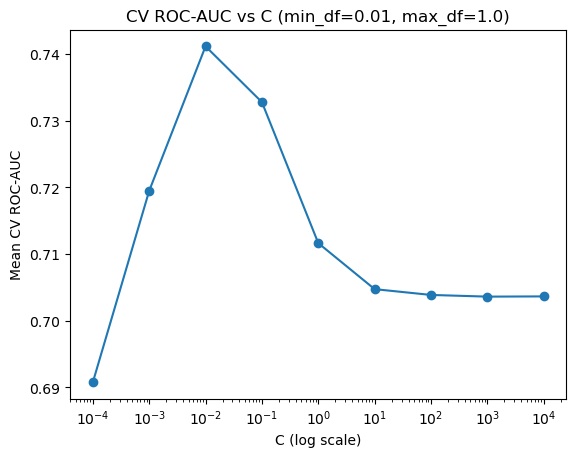

In [25]:
results = grid.cv_results_

# Hold BoW settings fixed at the best values so the plot is 1D vs C
best_min_df = grid.best_params_["my_bow_feature_extractor__min_df"]
best_max_df = grid.best_params_["my_bow_feature_extractor__max_df"]

Cs, mean_auc, std_auc = [], [], []

for i, p in enumerate(results["params"]):
    if (p["my_bow_feature_extractor__min_df"] == best_min_df and
        p["my_bow_feature_extractor__max_df"] == best_max_df):
        Cs.append(p["my_classifier__C"])
        mean_auc.append(results["mean_test_score"][i])
        std_auc.append(results["std_test_score"][i])

# Sort by C for a clean curve
order = np.argsort(Cs)
Cs = np.array(Cs)[order]
mean_auc = np.array(mean_auc)[order]
std_auc = np.array(std_auc)[order]

print(f"Holding min_df={best_min_df}, max_df={best_max_df}")
for c, m, s in zip(Cs, mean_auc, std_auc):
    print(f"C={c:>10g} | mean CV ROC-AUC={m:.4f} ± {s:.4f}")

plt.figure()
plt.plot(Cs, mean_auc, marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title(f"CV ROC-AUC vs C (min_df={best_min_df}, max_df={best_max_df})")
plt.show()

### Hyperparameter search results (figure + takeaway)
The figure below plots mean CV ROC-AUC vs `C` (log scale), using the best observed BoW settings.

**Takeaway:** (1–2 sentences)
- Performance pearks at ~ .74
- Extremely sensitive between .001 and .1 for Regularization

In [ ]:
# Print out the best parameter results
print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best parameters: {'my_bow_feature_extractor__max_df': 1.0, 'my_bow_feature_extractor__min_df': 0.01, 'my_classifier__C': np.float64(0.01)}
Best CV ROC-AUC: 0.7411572679533881


In [16]:
# Evaluate on test set (final unbiased score)
y_pred_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

Test ROC-AUC: 0.7376983867807458


## Model interpretation (feature weights)
After training the final model, we inspect the most positive/negative coefficients:
- positive weights push toward class 1 (Key Stage 4–5)
- negative weights push toward class 0 (Key Stage 2–3)

Note: these are correlations in this dataset

In [17]:
best_model = grid.best_estimator_
vectorizer = best_model.named_steps['my_bow_feature_extractor']
classifier = best_model.named_steps['my_classifier']

feature_names = vectorizer.get_feature_names_out()
weights = classifier.coef_[0]  # binary classification

In [18]:
# Pair words with weights
coef_df = pd.DataFrame({
    "word": feature_names,
    "weight": weights
}).sort_values("weight", ascending=False)

print("\nTop positive words:")
print(coef_df.head(20))

print("\nTop negative words:")
print(coef_df.tail(20))


Top positive words:
          word    weight
632      which  0.220527
491        sir  0.198098
193        for  0.167738
396         or  0.154181
483     should  0.153413
404        own  0.143400
567       thou  0.134812
557  therefore  0.130129
268    husband  0.128091
128      death  0.121674
16      almost  0.114742
629       when  0.114192
568     though  0.114108
480      shall  0.111686
401        our  0.109982
552      their  0.108783
38          as  0.104965
576        thy  0.104689
649    without  0.102068
238       hath  0.098190

Top negative words:
      word    weight
54   began -0.130734
74    boys -0.131375
403   over -0.133841
363    mrs -0.134256
66   black -0.134342
604     up -0.145316
179   felt -0.146165
277     it -0.146728
402    out -0.147011
578   time -0.147893
392    one -0.149403
635  white -0.153963
317     ll -0.164326
138    don -0.165777
544   talk -0.174257
458   said -0.175994
435     re -0.188413
362     mr -0.190101
40   asked -0.190243
388     oh -0

## 1D. Test-set prediction + export
Using the final selected model, we predict probabilities for each row of `x_test.csv`.

We export to `yproba1_test.txt`:
- one probability per line
- order must exactly match `x_test.csv`
- values represent `P(y=1 | text)`

In [ ]:
te_text_list = x_test_df['text'].values.tolist()
y_proba1_test = grid.best_estimator_.predict_proba(te_text_list)[:, 1]

In [20]:
print(y_proba1_test)
np.savetxt('yproba1_test.txt', y_proba1_test)

[0.79696247 0.71931085 0.85437404 ... 0.54480321 0.56613388 0.3892726 ]


## Reflection: validation vs outside-test AUROC gap
If AUROC differs significantly from CV AUROC, a likely cause is dataset shift:
- different topics/authors/styles between training folds vs test set
- BoW unigrams can overfit topic-specific vocabulary

Main takeaway: to improve performance in Problem 2, use representations that generalize better than raw unigram counts (e.g., character n-grams, length/style features, etc.)